In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/kenya.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


In [4]:
df["Country"] = "kenya"

In [5]:
df["date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

In [6]:
df["Month"] = df["date"].dt.month

In [7]:
df = df.replace(-999, np.nan)


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates()

In [10]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


In [11]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
date           0.0
Month          0.0
dtype: float64

In [12]:
missing_percent[missing_percent > 5]

Series([], dtype: float64)

In [13]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)

outliers = (z_scores.abs() > 3)
outliers_count = outliers.sum()

outliers_count

T2M             8
T2M_MAX         3
T2M_MIN         9
PRECTOTCORR    92
RH2M            6
WS2M            0
WS2M_MAX        6
dtype: int64

In [14]:
for col in cols:
    upper = df[col].mean() + 3 * df[col].std()
    lower = df[col].mean() - 3 * df[col].std()
    df[col] = np.clip(df[col], lower, upper)

In [15]:
df= df.ffill()

In [16]:
df=df.dropna()

In [18]:
df.to_csv("../data/kenya_clean.csv", index=False)

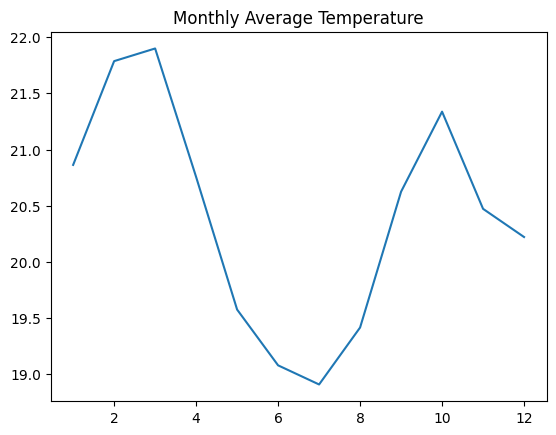

In [19]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.plot(monthly_temp.index, monthly_temp.values)
plt.title("Monthly Average Temperature")
plt.show()

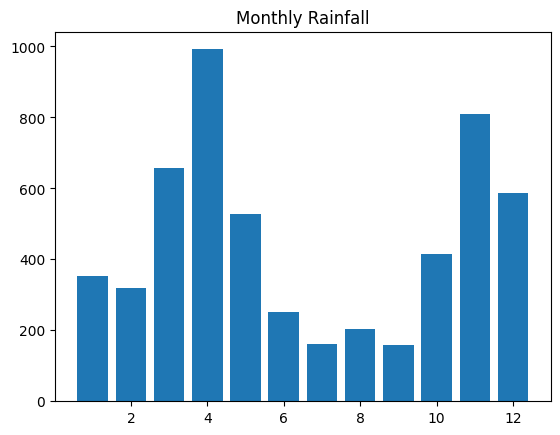

In [20]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Rainfall")
plt.show()

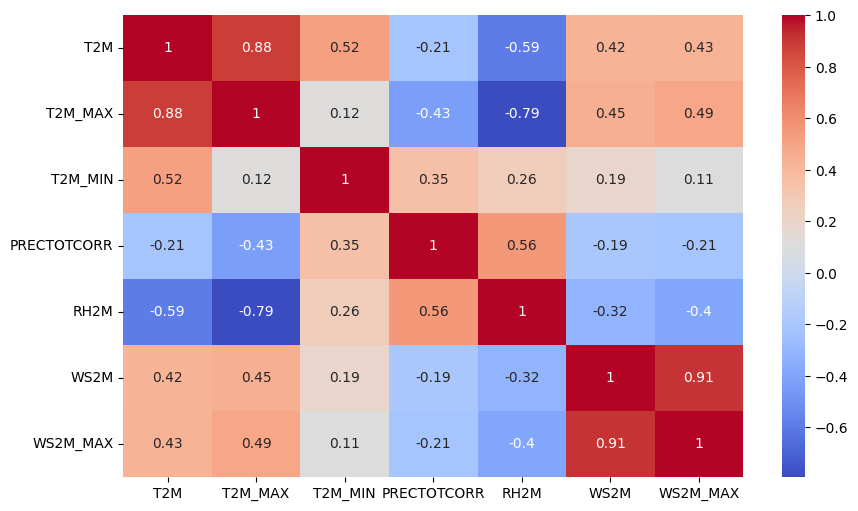

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.show()

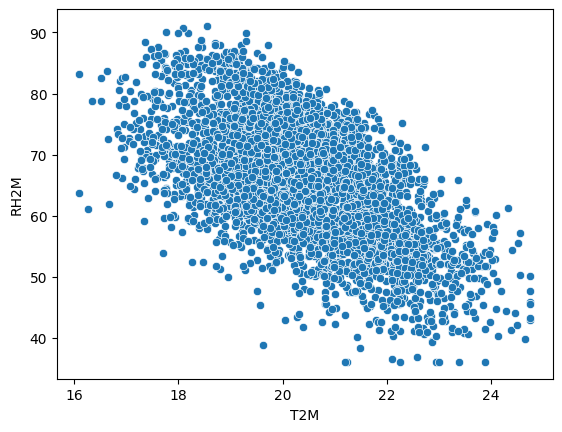

In [22]:
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.show()

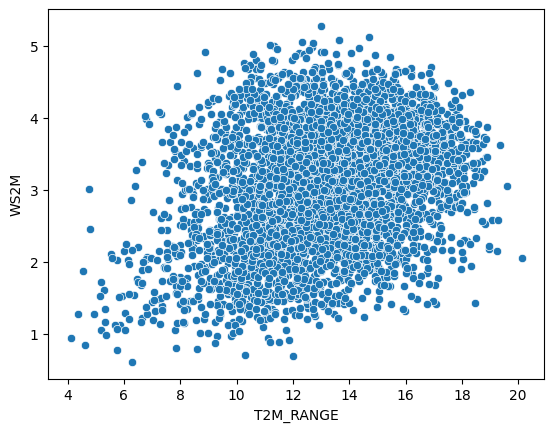

In [23]:
df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
plt.show()

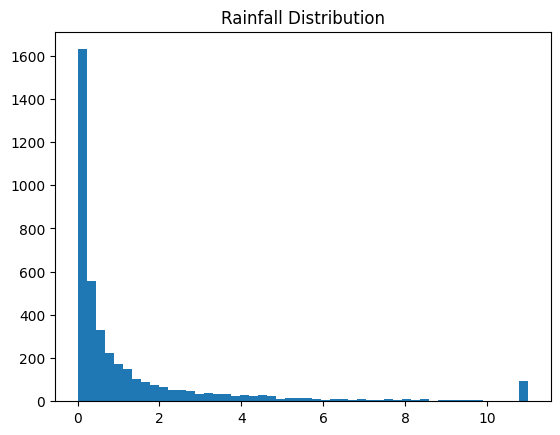

In [24]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution")
plt.show()

# Climate KPI Report

## Temperature Trends
The **Monthly Average Temperature** plot reveals a distinctive "bimodal" seasonal pattern rather than a simple single-peak curve:
* **Peak Period:** Temperatures reach their primary peak in **March (Month 3)** at nearly **22.0°C**.
* **The Mid-Year Dip:** A significant cooling period occurs mid-year, reaching the annual low in **July (Month 7)** at approximately **18.9°C**.
* **Secondary Peak:** Temperatures rise again in the autumn, peaking in **October (Month 10)** before a slight year-end decline.

## Rainfall Patterns
The **Monthly Rainfall** bar chart shows a highly variable and specific precipitation schedule:
* **Primary Wet Season:** Rainfall peaks dramatically in **April (Month 4)**, reaching nearly **1,000 units**.
* **Secondary Wet Season:** A second surge occurs in **November (Month 11)**, exceeding **800 units**.
* **Dry Period:** June through September represents the driest stretch of the year, with July and September showing the lowest accumulation.
* **Distribution:** The **Rainfall Distribution** histogram indicates a "long-tail" behavior. Most days have zero or very low rainfall (0–1 units), while a tiny fraction of days account for extreme precipitation events (seen in the outlier spike at the 11-unit mark).

##  Strongest Correlations
The **Correlation Heatmap** identifies the key environmental drivers for this dataset:
* **Wind Speed Consistency:** The strongest positive correlation is between **WS2M (Wind Speed)** and **WS2M_MAX** (**0.91**), indicating that days with high average winds almost always experience high peak gusts.
* **Temperature & Humidity:** There is a **strong negative correlation (-0.79)** between **T2M_MAX** and **RH2M**. This confirms that as maximum daily temperatures rise, the air's relative humidity drops significantly.
* **Rainfall & Humidity:** **PRECTOTCORR (Precipitation)** and **RH2M (Relative Humidity)** show a positive correlation of **0.56**, confirming that rainy periods are consistently associated with higher moisture levels.

##  Anomalies and Insights
* **Thermal Range vs. Wind:** The scatter plot for **WS2M vs. T2M_RANGE** shows a moderate positive trend. This suggests that days with a high "diurnal range" (large difference between day and night temperatures) tend to be windier.
* **Humidity Sensitivity:** The scatter plot for **RH2M vs. T2M** shows a clear downward-sloping cluster. This visualizes the physical principle that warmer air in this specific region typically holds less relative moisture, likely because the hottest periods do not overlap with the peak monsoon months.

---
**Summary Statement:** > *“Temperature and humidity show a negative correlation, meaning hotter months tend to be drier, while the climate is defined by twin rainfall peaks in April and November.”*